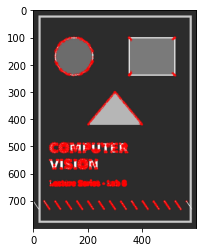

In [1]:
import cv2
import matplotlib.pyplot as plt
img= cv2.imread('image1.jpg', 0)

orb= cv2.ORB_create(nfeatures=5000)

kp,des=orb.detectAndCompute(img, None)

img_kp = cv2.drawKeypoints(img, kp, None, color=(255,0,0), flags=0)
plt.imshow(img_kp, cmap='gray')
plt.show()



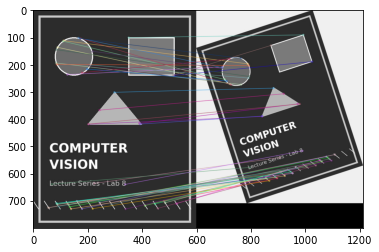

In [2]:
img1 = cv2.imread('image1.jpg', 0)
img2 = cv2.imread('image2.jpg', 0) 


kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key = lambda x:x.distance)

img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=2)

plt.imshow(img_matches, cmap='gray')
plt.show()



In [8]:
img = cv2.imread('image2.jpg', 0)

hog = cv2.HOGDescriptor()

hog_features = hog.compute(img)

print(f"HOG Feature Vector Shape: {hog_features.shape}")

HOG Feature Vector Shape: (19039860,)


Number of pedestrians detected: 7
Person 1: x=171, y=476, width=68, height=136, weight=1.1113
Person 2: x=260, y=614, width=72, height=144, weight=1.3209
Person 3: x=82, y=614, width=73, height=145, weight=1.9619
Person 4: x=144, y=612, width=74, height=148, weight=1.2239
Person 5: x=12, y=523, width=80, height=159, weight=0.8808
Person 6: x=208, y=613, width=73, height=146, weight=1.6576
Person 7: x=298, y=608, width=76, height=151, weight=0.7112


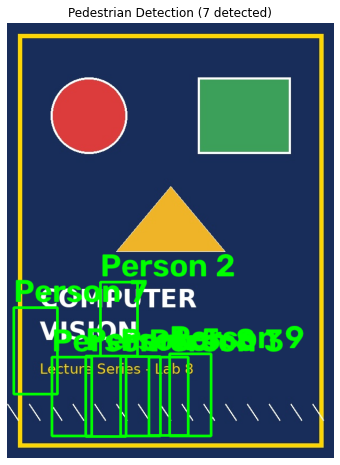

In [5]:
image = cv2.imread("image1.jpg")

if image is None:
    raise FileNotFoundError(
        "Image not found. Make sure 'street.jpg' exists."
    )

# Keep a copy for visualization
output = image.copy()



hog = cv2.HOGDescriptor()

hog.setSVMDetector(
    cv2.HOGDescriptor_getDefaultPeopleDetector()
)


(boxes, weights) = hog.detectMultiScale(
    image,
    winStride=(4, 4),
    padding=(4, 4),
    scale=1.05
)


c_t = 0.6
f_d = []
for i, ((x, y, w, h), weight) in enumerate(
    zip(boxes, weights)
):
    c = float(weight)
    if c > c_t:
        f_d.append(
            ((x, y, w, h), c)
        )

        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            4
        )

        label = f"Person {i + 1}"

        cv2.putText(
            output,
            label,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            2,
            (0, 255, 0),
            4
        )



print(f"Number of pedestrians detected: {len(f_d)}")

for i, ((x, y, w, h), confidence) in enumerate(
    f_d
):
    print(
        f"Person {i + 1}: "
        f"x={x}, y={y}, width={w}, height={h}, "
        f"weight={float(confidence):.4f}"
    )


output_rgb = cv2.cvtColor(
    output,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))
plt.imshow(output_rgb)
plt.title(
    f"Pedestrian Detection "
    f"({len(f_d)} detected)"
)
plt.axis("off")
plt.show()

